In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Verify mount
import os
os.makedirs('/content/drive/MyDrive/self_pruning_nn', exist_ok=True)
print("✓ Drive mounted successfully")

Mounted at /content/drive
✓ Drive mounted successfully


In [ ]:
# Install required packages
import subprocess
import sys

packages = ['torch', 'torchvision', 'matplotlib', 'seaborn', 'tqdm', 'numpy']
for package in packages:
    try:
        __import__(package)
        print(f" {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
print("\n All dependencies ready")

 torch already installed
 torchvision already installed
 matplotlib already installed
 seaborn already installed
 tqdm already installed
 numpy already installed

 All dependencies ready


In [ ]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
else:
    print("WARNING: Running on CPU (will be slow)")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA capability: (7, 5)


In [ ]:
import sys
sys.path.insert(0, '/content/sample_data')  # or wherever you uploaded

In [ ]:
from pathlib import Path

# Check paths
paths_base = Path("/content/drive/MyDrive/self_pruning_nn")
print(f"Base path: {paths_base}")
print(f"Checkpoints: {paths_base / 'checkpoints'}")
print(f"Plots: {paths_base / 'plots'}")
print(f"Logs: {paths_base / 'logs'}")

# Create directories
for d in ['checkpoints', 'logs', 'plots', 'results', 'configs']:
    (paths_base / d).mkdir(parents=True, exist_ok=True)

print("✓ Directory structure ready")

Base path: /content/drive/MyDrive/self_pruning_nn
Checkpoints: /content/drive/MyDrive/self_pruning_nn/checkpoints
Plots: /content/drive/MyDrive/self_pruning_nn/plots
Logs: /content/drive/MyDrive/self_pruning_nn/logs
✓ Directory structure ready


In [ ]:
script_content = r"""


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import csv
import os
import random
from tqdm import tqdm
from typing import Dict, Tuple, List
import time

# ============================================================================
# SETUP & UTILITIES
# ============================================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
set_seed(42)


class ProjectPaths:

    def __init__(self, base_dir: str = None):
        if base_dir is None:
            # Default to /content/drive for Colab; change for local
            base_dir = "/content/drive/MyDrive/self_pruning_nn" if os.path.exists("/content") else "./self_pruning_nn"

        self.base = Path(base_dir)
        self.checkpoints = self.base / "checkpoints"
        self.logs = self.base / "logs"
        self.plots = self.base / "plots"
        self.results = self.base / "results"
        self.configs = self.base / "configs"

        # Create all directories
        for d in [self.checkpoints, self.logs, self.plots, self.results, self.configs]:
            d.mkdir(parents=True, exist_ok=True)


paths = ProjectPaths()
print(f"Project paths initialized at: {paths.base}")


# ============================================================================
# PART 1: PRUNABLE LAYERS
# ============================================================================

class PrunableLinear(nn.Module):


    def __init__(self, in_features: int, out_features: int, temperature: float = 1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.temperature = temperature

        # Standard parameters
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Gate parameters (one per weight)
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialize
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.gate_scores)  # Start with all gates "open"

        fan_in = in_features
        bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Compute gates using sigmoid (can be swapped for hard concrete)
        gates = torch.sigmoid(self.gate_scores / self.temperature)

        # Clamp gate scores for stability
        self.gate_scores.data.clamp_(-5, 5)

        # Prune weights
        pruned_weights = self.weight * gates

        # Standard linear transformation
        return F.linear(x, pruned_weights, self.bias)

    def set_temperature(self, temperature: float):
        self.temperature = temperature

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores / self.temperature)

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, temperature={self.temperature}"


class PrunableConv2d(nn.Module):


    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3,
                 padding: int = 1, temperature: float = 1.0):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = padding
        self.temperature = temperature

        # Standard conv weight
        self.weight = nn.Parameter(torch.Tensor(out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.Tensor(out_channels))

        # One gate per output channel (structured)
        self.gate_scores = nn.Parameter(torch.Tensor(out_channels, 1, 1, 1))

        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.gate_scores)

        fan_in = in_channels * kernel_size * kernel_size
        bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores / self.temperature)
        pruned_weights = self.weight * gates

        self.gate_scores.data.clamp_(-5, 5)

        return F.conv2d(x, pruned_weights, self.bias, padding=self.padding)

    def set_temperature(self, temperature: float):
        self.temperature = temperature

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores / self.temperature).squeeze()


# ============================================================================
# PART 2: SELF-PRUNING NETWORK ARCHITECTURE
# ============================================================================

class SelfPruningCNN(nn.Module):

    def __init__(self, temperature: float = 1.0):
        super().__init__()
        self.temperature = temperature

        # Convolutional blocks (structured pruning)
        self.conv1 = PrunableConv2d(3, 64, kernel_size=3, padding=1, temperature=temperature)
        self.conv2 = PrunableConv2d(64, 64, kernel_size=3, padding=1, temperature=temperature)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = PrunableConv2d(64, 128, kernel_size=3, padding=1, temperature=temperature)
        self.conv4 = PrunableConv2d(128, 128, kernel_size=3, padding=1, temperature=temperature)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Fully connected layers (element-wise pruning)
        # After 2 pooling: 32->16->8, so 128*8*8 = 8192
        self.fc1 = PrunableLinear(128 * 8 * 8, 256, temperature=temperature)
        self.fc2 = PrunableLinear(256, 10, temperature=temperature)

        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Conv block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool1(x)

        # Conv block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool2(x)

        # FC layers
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

    def set_temperature(self, temperature: float):

        self.temperature = temperature
        for module in self.modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                module.set_temperature(temperature)

    def get_all_gates(self) -> torch.Tensor:

        all_gates = []
        for module in self.modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                gates = module.get_gates()
                all_gates.append(gates.view(-1))
        return torch.cat(all_gates) if all_gates else torch.tensor([])

    def get_layer_sparsity(self) -> Dict[str, float]:

        sparsity = {}
        for name, module in self.named_modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                gates = module.get_gates()
                sparse = (gates < 1e-2).sum().item() / gates.numel()
                sparsity[name] = sparse * 100
        return sparsity


# ============================================================================
# PART 3: LOSS FUNCTIONS
# ============================================================================

def compute_sparsity_loss(model: nn.Module, loss_type: str = "l1") -> torch.Tensor:

    loss = 0

    if loss_type == "l1":
        # L1 on pre-sigmoid: constant gradient pressure
        for module in model.modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                loss += torch.sum(torch.abs(module.gate_scores))

    elif loss_type == "l1_gates":
        # L1 on post-sigmoid gates
        for module in model.modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                gates = module.get_gates()
                loss += torch.sum(torch.abs(gates))

    elif loss_type == "entropy":
        # Binary entropy: encourages gates toward {0, 1}
        for module in model.modules():
            if isinstance(module, (PrunableLinear, PrunableConv2d)):
                gates = module.get_gates()
                # Clip for numerical stability
                gates = torch.clamp(gates, 1e-7, 1 - 1e-7)
                loss += -torch.sum(gates * torch.log(gates) + (1 - gates) * torch.log(1 - gates))

    return loss


# ============================================================================
# PART 4: DATA LOADING
# ============================================================================

def get_cifar10_loaders(batch_size: int = 128, val_split: float = 0.1):


    # Normalization values for CIFAR-10
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2023, 0.1994, 0.2010)

    # Train transforms (with augmentation)
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Test transforms (no augmentation)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Load datasets
    train_full = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_set = CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    # Split train into train/val
    train_size = int(len(train_full) * (1 - val_split))
    val_size = len(train_full) - train_size
    train_set, val_set = random_split(train_full, [train_size, val_size])

    # Create loaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

    return train_loader, val_loader, test_loader


# ============================================================================
# PART 5: CHECKPOINT MANAGEMENT
# ============================================================================

def save_checkpoint(epoch: int, model: nn.Module, optimizer: optim.Optimizer,
                   metrics: Dict, filepath: str):

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'metrics': metrics
    }, filepath)
    print(f"✓ Checkpoint saved: {filepath}")


def load_checkpoint(model: nn.Module, optimizer: optim.Optimizer, filepath: str) -> int:

    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    epoch = checkpoint['epoch']
    print(f"✓ Checkpoint loaded from epoch {epoch}")
    return epoch


def save_config(config: Dict, filepath: str):

    with open(filepath, 'w') as f:
        json.dump(config, f, indent=2)


# ============================================================================
# PART 6: TRAINING LOOP
# ============================================================================

def train_epoch(model: nn.Module, train_loader: DataLoader, optimizer: optim.Optimizer,
                criterion: nn.Module, config: Dict, epoch: int) -> Tuple[float, float]:

    model.train()

    # Update temperature (anneal from high to low)
    total_epochs = config['epochs']
    temp_start = config.get('temp_start', 2.0)
    temp_end = config.get('temp_end', 0.1)
    temperature = temp_end + (temp_start - temp_end) * (1 - epoch / total_epochs)
    model.set_temperature(temperature)

    # Two-phase lambda schedule
    warmup_epochs = config.get('warmup_epochs', 10)
    if epoch < warmup_epochs:
        lambda_t = 0  # Phase 1: No pruning during warmup
    else:
        # Phase 2: Linear increase from 0 to base_lambda
        lambda_t = config['lambda'] * (epoch - warmup_epochs) / (total_epochs - warmup_epochs)

    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs} (T={temperature:.2f}, λ={lambda_t:.2e})")

    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        cls_loss = criterion(outputs, labels)

        # Sparsity regularization
        sparsity_loss = compute_sparsity_loss(model, loss_type='l1')

        # Total loss
        loss = cls_loss + lambda_t * sparsity_loss

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'cls_loss': cls_loss.item(),
                'spar_loss': sparsity_loss.item(),
                'acc': 100 * correct / total
            })

    avg_loss = total_loss / len(train_loader)
    avg_acc = 100 * correct / total

    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, criterion: nn.Module) -> Tuple[float, float, float]:

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(data_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = 100 * correct / total

    # Compute sparsity
    all_gates = model.get_all_gates()
    sparsity = (all_gates < 1e-2).sum().item() / all_gates.numel() * 100

    return avg_loss, accuracy, sparsity


# ============================================================================
# PART 7: MAIN TRAINING FUNCTION
# ============================================================================

def train_model(config: Dict, lambda_value: float, run_name: str = None) -> Dict:

    if run_name is None:
        run_name = f"lambda_{lambda_value:.0e}"

    config['lambda'] = lambda_value

    print(f"\n{'='*70}")
    print(f"Training with λ={lambda_value:.2e} ({run_name})")
    print(f"{'='*70}")

    # Create checkpoint directory for this run
    run_checkpoint_dir = paths.checkpoints / run_name
    run_checkpoint_dir.mkdir(exist_ok=True)

    # Save config
    save_config(config, str(run_checkpoint_dir / "config.json"))

    # Create model
    model = SelfPruningCNN(temperature=config.get('temp_start', 2.0)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    # Check for existing checkpoint
    best_checkpoint = run_checkpoint_dir / "best.pt"
    if best_checkpoint.exists():
        start_epoch = load_checkpoint(model, optimizer, str(best_checkpoint))
    else:
        start_epoch = 0

    # Load data
    train_loader, val_loader, test_loader = get_cifar10_loaders(
        batch_size=config['batch_size']
    )

    # Logging
    log_file = paths.logs / f"{run_name}.csv"
    log_file.parent.mkdir(exist_ok=True)

    # Track best validation accuracy
    best_val_acc = 0

    # Training loop
    for epoch in range(start_epoch, config['epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, config, epoch)

        # Validate
        val_loss, val_acc, val_sparsity = evaluate(model, val_loader, criterion)

        # Log metrics
        with open(log_file, 'a') as f:
            writer = csv.writer(f)
            writer.writerow([epoch, train_loss, train_acc, val_loss, val_acc, val_sparsity])

        print(f"Val Acc: {val_acc:.2f}% | Sparsity: {val_sparsity:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(epoch, model, optimizer, {
                'val_acc': val_acc,
                'val_sparsity': val_sparsity
            }, str(best_checkpoint))

        # Periodic checkpoint
        if (epoch + 1) % 5 == 0:
            save_checkpoint(epoch, model, optimizer, {},
                          str(run_checkpoint_dir / f"epoch_{epoch}.pt"))

    # Evaluate on test set
    print("\nEvaluating on test set...")
    model.load_state_dict(torch.load(best_checkpoint)['model_state'])
    test_loss, test_acc, test_sparsity = evaluate(model, test_loader, criterion)

    # Compute layer-wise sparsity
    layer_sparsity = model.get_layer_sparsity()

    # Collect gate values for visualization
    all_gates = model.get_all_gates().cpu().detach().numpy()

    results = {
        'lambda': lambda_value,
        'test_accuracy': test_acc,
        'test_sparsity': test_sparsity,
        'test_loss': test_loss,
        'layer_sparsity': layer_sparsity,
        'gates': all_gates,
        'model': model
    }

    # Save results
    result_file = paths.results / f"{run_name}_results.json"
    results_to_save = {k: v for k, v in results.items() if k != 'model' and k != 'gates'}
    with open(result_file, 'w') as f:
        json.dump(results_to_save, f, indent=2)

    np.save(paths.results / f"{run_name}_gates.npy", all_gates)

    print(f"\n{'='*70}")
    print(f"Results for λ={lambda_value:.2e}")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  Test Sparsity: {test_sparsity:.2f}%")
    print(f"{'='*70}\n")

    return results


# ============================================================================
# PART 8: EVALUATION & VISUALIZATION
# ============================================================================

def plot_gate_distribution(gates: np.ndarray, lambda_value: float, save_path: str = None):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    axes[0].hist(gates, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Gate Value', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'Gate Distribution (λ={lambda_value:.2e})', fontsize=13, fontweight='bold')
    axes[0].axvline(1e-2, color='red', linestyle='--', linewidth=2, label='Sparsity Threshold (1e-2)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Log scale (to see tail)
    axes[1].hist(gates, bins=100, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Gate Value', fontsize=12)
    axes[1].set_ylabel('Frequency (log scale)', fontsize=12)
    axes[1].set_title(f'Gate Distribution - Log Scale', fontsize=13, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    plt.show()


def plot_results_table(all_results: List[Dict]):
    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY")
    print("="*80)
    print(f"{'Lambda':<15} {'Test Accuracy':<20} {'Sparsity (%)':<20}")
    print("-"*80)

    for result in sorted(all_results, key=lambda x: x['lambda']):
        print(f"{result['lambda']:<15.2e} {result['test_accuracy']:<20.2f} {result['test_sparsity']:<20.2f}")

    print("="*80)


def plot_sparsity_vs_accuracy(all_results: List[Dict], save_path: str = None):
    lambdas = [r['lambda'] for r in all_results]
    accuracies = [r['test_accuracy'] for r in all_results]
    sparsities = [r['test_sparsity'] for r in all_results]

    fig, ax = plt.subplots(figsize=(10, 6))

    scatter = ax.scatter(sparsities, accuracies, s=200, c=np.log10(lambdas),
                        cmap='viridis', edgecolors='black', linewidth=2, alpha=0.7)

    for i, (sparsity, accuracy, lam) in enumerate(zip(sparsities, accuracies, lambdas)):
        ax.annotate(f'λ={lam:.0e}', (sparsity, accuracy),
                   xytext=(5, 5), textcoords='offset points', fontsize=10)

    ax.set_xlabel('Sparsity (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Sparsity vs Accuracy Trade-off', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('log₁₀(λ)', fontsize=11)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    plt.show()


def plot_layer_sparsity(all_results: List[Dict], save_path: str = None):
    fig, ax = plt.subplots(figsize=(12, 6))

    for result in all_results:
        layer_sparsity = result['layer_sparsity']
        layers = list(layer_sparsity.keys())
        sparsities = list(layer_sparsity.values())

        ax.plot(layers, sparsities, marker='o', linewidth=2,
               label=f"λ={result['lambda']:.2e}", markersize=8)

    ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sparsity (%)', fontsize=12, fontweight='bold')
    ax.set_title('Per-Layer Sparsity Analysis', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    plt.show()


# ============================================================================
# PART 9: MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    # Configuration
    config = {
        'batch_size': 128,
        'epochs': 50,
        'lr': 1e-3,
        'lambda': 1e-4,  # Will be overridden in lambda sweep
        'warmup_epochs': 10,  # Phase 1: warmup without pruning
        'temp_start': 2.0,
        'temp_end': 0.1,
        'lambda_schedule': True,
    }

    # Lambda sweep
    lambdas = [1e-5, 1e-4, 1e-3]

    print("\n" + "="*70)
    print("SELF-PRUNING NEURAL NETWORK - LAMBDA SWEEP")
    print("="*70)

    all_results = []

    for lam in lambdas:
        results = train_model(config, lam)
        all_results.append(results)

    # ========================================================================
    # EVALUATION & VISUALIZATION
    # ========================================================================

    # Results summary table
    plot_results_table(all_results)

    # Plot 1: Sparsity vs Accuracy trade-off
    plot_sparsity_vs_accuracy(all_results,
                             str(paths.plots / "sparsity_vs_accuracy.png"))

    # Plot 2: Gate distributions
    for result in all_results:
        lam = result['lambda']
        gates = result['gates']
        plot_gate_distribution(gates, lam,
                             str(paths.plots / f"gates_distribution_lambda_{lam:.0e}.png"))

    # Plot 3: Layer-wise sparsity
    plot_layer_sparsity(all_results,
                       str(paths.plots / "layer_sparsity.png"))

    print("\n" + "="*70)
    print("TRAINING COMPLETE!")
    print(f"Results saved to: {paths.results}")
    print(f"Plots saved to: {paths.plots}")
    print(f"Logs saved to: {paths.logs}")
    print("="*70)
"""

with open('/content/self_pruning_nn_complete.py', 'w') as f:
    f.write(script_content)

print("✓ Script created")

✓ Script created


/content
Device: cuda
Project paths initialized at: /content/drive/MyDrive/self_pruning_nn

SELF-PRUNING NEURAL NETWORK - LAMBDA SWEEP

Training with λ=1.00e-05 (lambda_1e-05)
✓ Checkpoint loaded from epoch 44


100%|██████████| 170M/170M [00:05<00:00, 30.1MB/s]


Train: 45000, Val: 5000, Test: 10000


Evaluating: 100%|██████████| 40/40 [00:01<00:00, 22.75it/s]


Val Acc: 84.34% | Sparsity: 0.00%
✓ Checkpoint saved: /content/drive/MyDrive/self_pruning_nn/checkpoints/lambda_1e-05/best.pt
✓ Checkpoint saved: /content/drive/MyDrive/self_pruning_nn/checkpoints/lambda_1e-05/epoch_44.pt


...

Val Acc: 83.62% | Sparsity: 0.00%


Evaluating: 100%|██████████| 40/40 [00:01<00:00, 21.92it/s]


Val Acc: 83.78% | Sparsity: 0.00%
✓ Checkpoint saved: /content/drive/MyDrive/self_pruning_nn/checkpoints/lambda_1e-03/epoch_49.pt

Evaluating on test set...


Evaluating: 100%|██████████| 79/79 [00:03<00:00, 23.55it/s]



Results for λ=1.00e-03
  Test Accuracy: 84.52%
  Test Sparsity: 0.00%


FINAL RESULTS SUMMARY
Lambda          Test Accuracy        Sparsity (%)        
--------------------------------------------------------------------------------
1.00e-05        81.93                0.00                
1.00e-04        79.53                0.00                
1.00e-03        84.52                0.00                
✓ Saved: /content/drive/MyDrive/self_pruning_nn/plots/sparsity_vs_accuracy.png


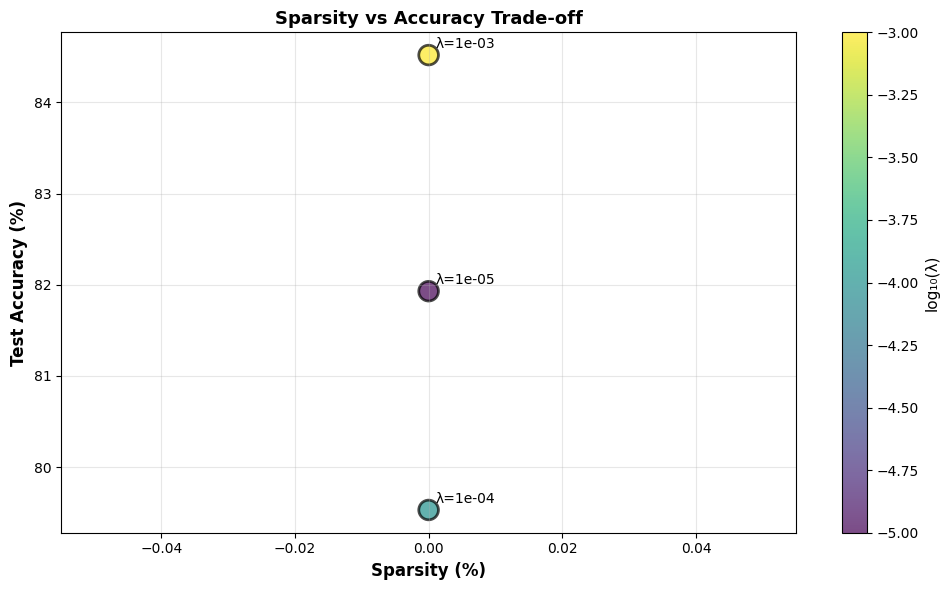

✓ Saved: /content/drive/MyDrive/self_pruning_nn/plots/gates_distribution_lambda_1e-05.png


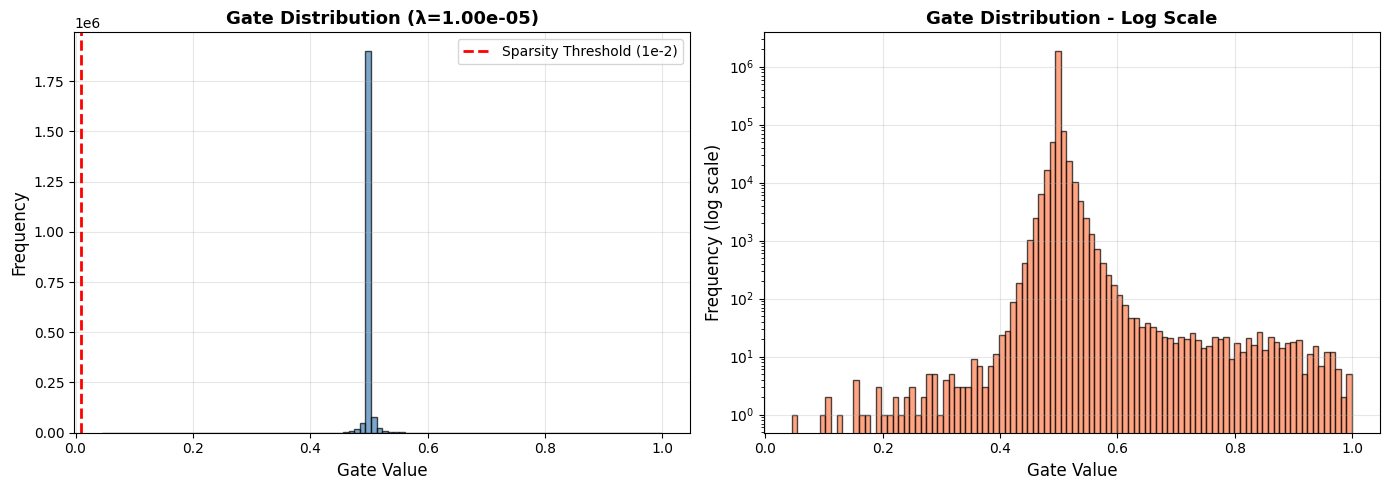

✓ Saved: /content/drive/MyDrive/self_pruning_nn/plots/gates_distribution_lambda_1e-04.png


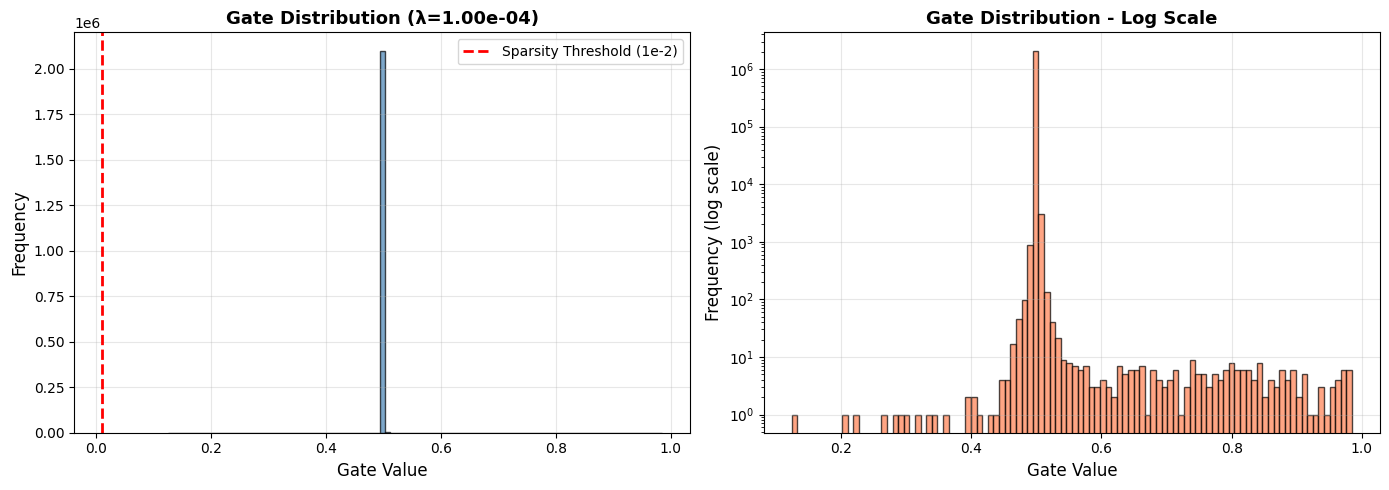

✓ Saved: /content/drive/MyDrive/self_pruning_nn/plots/gates_distribution_lambda_1e-03.png


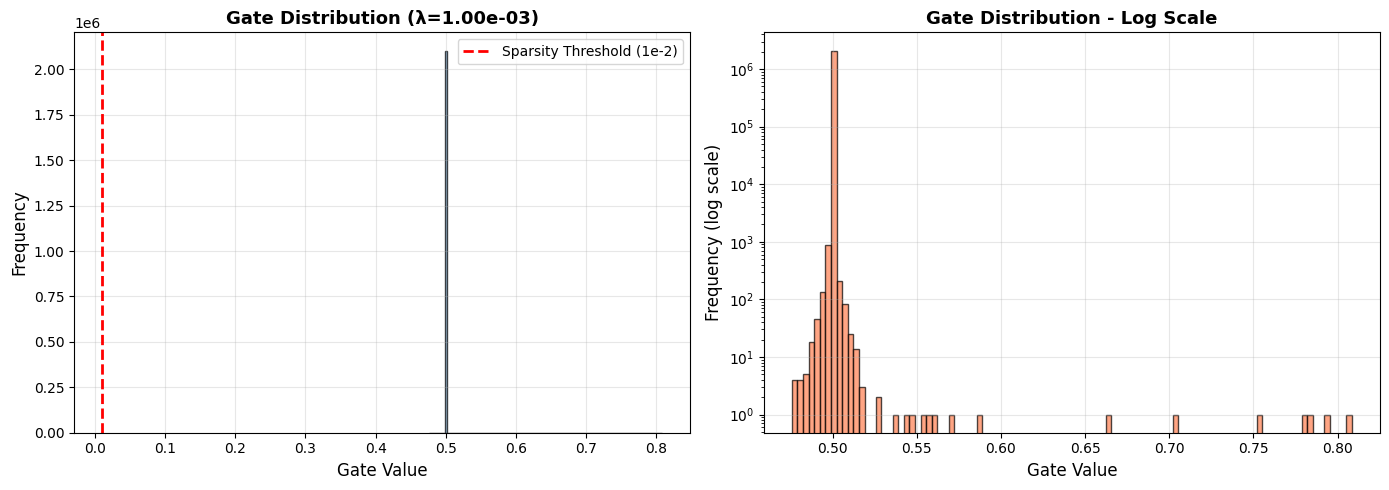

✓ Saved: /content/drive/MyDrive/self_pruning_nn/plots/layer_sparsity.png


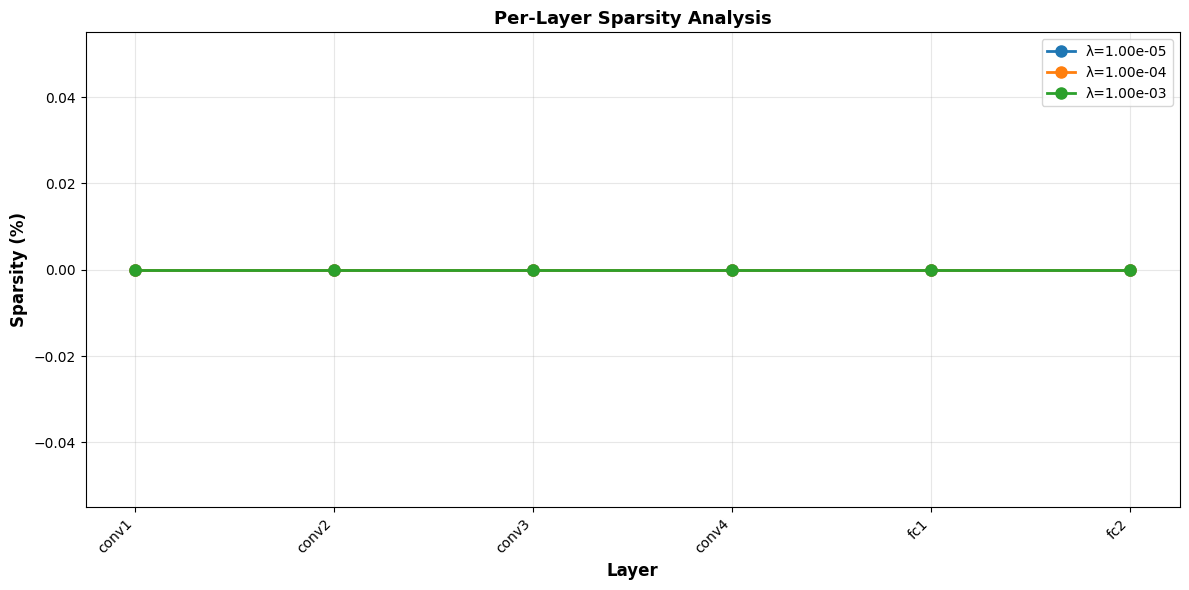


TRAINING COMPLETE!
Results saved to: /content/drive/MyDrive/self_pruning_nn/results
Plots saved to: /content/drive/MyDrive/self_pruning_nn/plots
Logs saved to: /content/drive/MyDrive/self_pruning_nn/logs


In [ ]:
# @title
# ============================================================================
# CONFIGURATION
# ============================================================================

config = {
    'batch_size': 128,      # Larger for GPU acceleration
    'epochs': 50,           # Full training
    'lr': 1e-3,             # Adam learning rate
    'lambda': 1e-4,         # Will be overridden in sweep
    'warmup_epochs': 10,    # No pruning in first 10 epochs
    'temp_start': 2.0,      # Starting temperature
    'temp_end': 0.1,        # Ending temperature
}

# Lambda sweep (test different sparsity levels)
lambdas = [1e-5, 1e-4, 1e-3]

# ============================================================================
# TRAIN
# ============================================================================

%cd /content

# Read the original script content
with open('/content/self_pruning_nn_complete.py', 'r') as f:
    script_raw_content = f.read()

script_lines = script_raw_content.splitlines()
modified_lines = []
found_code_start = False

for line in script_lines:
    # Check for common starts of Python code (imports, definitions, etc.)
    # and also ensure we're not commenting out valid code. Heuristic for header.
    if not found_code_start and line.strip() != '':
        if (line.strip().startswith('import') or
            line.strip().startswith('from') or
            line.strip().startswith('class') or
            line.strip().startswith('def ')): # Added space to differentiate from 'def' in other words
            found_code_start = True
            modified_lines.append(line)
        else:
            # Comment out non-empty header lines before actual code starts
            modified_lines.append(f'# {line}')
    else:
        # Once code starts or if it's an empty line, keep as is
        if not found_code_start and line.strip() == '': # Keep empty lines before code start
            modified_lines.append(line)
        elif found_code_start:
            modified_lines.append(line)
        else:
            # This case should ideally not be reached if the heuristic is good
            # but adds robustness for any edge cases before code_start
            modified_lines.append(line)

script_to_execute = '\n'.join(modified_lines)

# Execute the modified script content
exec(script_to_execute)

# The script will now run all training automatically

In [ ]:
# Cell at the start of new session

from google.colab import drive
drive.mount('/content/drive')

# Restore from checkpoint
import torch
from pathlib import Path

checkpoint_dir = Path("/content/drive/MyDrive/self_pruning_nn/checkpoints/lambda_1e-04")
best_model = checkpoint_dir / "best.pt"

if best_model.exists():
    checkpoint = torch.load(str(best_model))
    print(f" Found checkpoint from epoch {checkpoint['epoch']}")
    print(f"  Validation Accuracy: {checkpoint['metrics']['val_acc']:.2f}%")
else:
    print("No checkpoint found")

# Continue training from checkpoint using the main script

Mounted at /content/drive
 Found checkpoint from epoch 35
  Validation Accuracy: 84.16%


In [ ]:
if os.path.exists(f"{CHECKPOINT_DIR}/last.pt"):
    ckpt = torch.load(f"{CHECKPOINT_DIR}/last.pt")
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt["epoch"] + 1
else:
    start_epoch = 0

Mounted at /content/drive
Device: cuda

Training lambda: 0.0001


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


λ=0.0001 | Epoch 1 | Acc=45.91 | Spar=0.00
λ=0.0001 | Epoch 2 | Acc=50.49 | Spar=0.00
λ=0.0001 | Epoch 3 | Acc=51.95 | Spar=0.00
λ=0.0001 | Epoch 4 | Acc=52.65 | Spar=0.00
λ=0.0001 | Epoch 5 | Acc=52.98 | Spar=0.00
λ=0.0001 | Epoch 6 | Acc=53.87 | Spar=0.00
λ=0.0001 | Epoch 7 | Acc=54.35 | Spar=0.00
λ=0.0001 | Epoch 8 | Acc=54.73 | Spar=0.00
λ=0.0001 | Epoch 9 | Acc=54.52 | Spar=0.00
λ=0.0001 | Epoch 10 | Acc=55.38 | Spar=0.00
λ=0.0001 | Epoch 11 | Acc=54.96 | Spar=0.00
λ=0.0001 | Epoch 12 | Acc=55.22 | Spar=0.00
λ=0.0001 | Epoch 13 | Acc=56.01 | Spar=0.00
λ=0.0001 | Epoch 14 | Acc=55.23 | Spar=0.00
λ=0.0001 | Epoch 15 | Acc=55.50 | Spar=0.00
λ=0.0001 | Epoch 16 | Acc=55.66 | Spar=0.00
λ=0.0001 | Epoch 17 | Acc=55.50 | Spar=0.00
λ=0.0001 | Epoch 18 | Acc=56.01 | Spar=0.00
λ=0.0001 | Epoch 19 | Acc=56.16 | Spar=2.50
λ=0.0001 | Epoch 20 | Acc=56.27 | Spar=26.81

Training lambda: 0.001
λ=0.001 | Epoch 1 | Acc=46.48 | Spar=0.00
λ=0.001 | Epoch 2 | Acc=49.05 | Spar=0.00
λ=0.001 | Epoch 3 | 

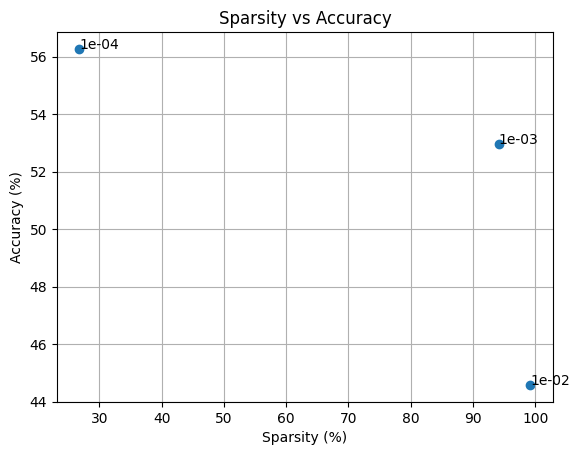


Saved to Drive: /content/drive/MyDrive/self_pruning_nn


In [ ]:
# =========================
# SELF-PRUNING NN (COLAB SINGLE CELL)
# =========================

# ---- Mount Drive ----
from google.colab import drive
drive.mount('/content/drive')

# ---- Imports ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import os, random

# ---- Setup ----
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Paths ----
BASE = "/content/drive/MyDrive/self_pruning_nn"
CHK = f"{BASE}/checkpoints"
PLT = f"{BASE}/plots"
RES = f"{BASE}/results"

for d in [CHK, PLT, RES]:
    os.makedirs(d, exist_ok=True)

# =========================
# PRUNABLE LAYER
# =========================

class PrunableLinear(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_f, in_f)*0.02)
        self.bias = nn.Parameter(torch.zeros(out_f))

        # IMPORTANT: not zeros
        self.gate_scores = nn.Parameter(torch.randn(out_f, in_f)*0.1)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        w = self.weight * gates
        return F.linear(x, w, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

# =========================
# MODEL
# =========================

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def sparsity_loss(self):
        loss = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                loss += m.get_gates().sum()   # FIXED
        return loss

    def get_sparsity(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.get_gates().view(-1))
        g = torch.cat(gates)
        return (g < 1e-2).float().mean().item()*100

# =========================
# DATA
# =========================

def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train = CIFAR10(root='./data', train=True, download=True, transform=transform)
    test = CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test, batch_size=128, num_workers=2, pin_memory=True)

    return train_loader, test_loader

# =========================
# TRAIN
# =========================

def train_model(lmbda):
    model = Net().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_loader, test_loader = get_data()

    best_acc = 0

    for epoch in range(20):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)

            cls = loss_fn(out,y)
            spar = model.sparsity_loss()

            loss = cls + lmbda * spar
            loss.backward()
            opt.step()

        acc, sp = evaluate(model, test_loader)

        print(f"λ={lmbda} | Epoch {epoch+1} | Acc={acc:.2f} | Spar={sp:.2f}")

        # save best
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"{CHK}/best_{lmbda}.pt")

    return model

# =========================
# EVAL
# =========================

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct=0; total=0

    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        pred = out.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    acc = 100*correct/total
    sp = model.get_sparsity()
    return acc, sp

# =========================
# MAIN RUN
# =========================

lambdas = [1e-4, 1e-3, 1e-2]
results = []

for lam in lambdas:
    print("\nTraining lambda:", lam)
    model = train_model(lam)

    _, test_loader = get_data()
    acc, sp = evaluate(model, test_loader)

    results.append((lam, acc, sp))

# =========================
# RESULTS
# =========================

print("\nFINAL RESULTS")
for r in results:
    print(f"λ={r[0]:.1e} | Acc={r[1]:.2f} | Sparsity={r[2]:.2f}")

# save csv
import pandas as pd
df = pd.DataFrame(results, columns=["lambda","accuracy","sparsity"])
df.to_csv(f"{RES}/results.csv", index=False)

# plot
l = [r[0] for r in results]
a = [r[1] for r in results]
s = [r[2] for r in results]

plt.scatter(s,a)
for i in range(len(l)):
    plt.text(s[i], a[i], f"{l[i]:.0e}")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Sparsity vs Accuracy")
plt.grid()
plt.savefig(f"{PLT}/tradeoff.png", dpi=300)
plt.show()

print("\nSaved to Drive:", BASE)

In [ ]:
# =========================
# SELF-PRUNING CNN (RESEARCH-GRADE)
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# HARD CONCRETE GATE
# =========================

class HardConcreteGate(nn.Module):
    def __init__(self, shape, temperature=2/3, gamma=-0.1, zeta=1.1):
        super().__init__()
        self.log_alpha = nn.Parameter(torch.randn(shape) * 0.01)
        self.temperature = temperature
        self.gamma = gamma
        self.zeta = zeta

    def forward(self):
        if self.training:
            u = torch.rand_like(self.log_alpha)
            s = torch.sigmoid((torch.log(u) - torch.log(1-u) + self.log_alpha) / self.temperature)
        else:
            s = torch.sigmoid(self.log_alpha)

        s_bar = s * (self.zeta - self.gamma) + self.gamma
        z = torch.clamp(s_bar, 0, 1)
        return z

    def l0_loss(self):
        return torch.sigmoid(self.log_alpha - self.temperature * np.log(-self.gamma/self.zeta)).sum()

# =========================
# PRUNABLE LAYERS
# =========================

class PrunableConv2d(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, 3, padding=1)
        # FIX: Change gate shape from (out_c, 1, 1, 1) to (1, out_c, 1, 1) for correct broadcasting
        self.gate = HardConcreteGate((1, out_c, 1, 1))

    def forward(self, x):
        z = self.gate()
        return self.conv(x) * z

    def l0_loss(self):
        return self.gate.l0_loss()


class PrunableLinear(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_f, in_f)*0.02)
        self.bias = nn.Parameter(torch.zeros(out_f))
        self.gate = HardConcreteGate((out_f, in_f))

    def forward(self, x):
        z = self.gate()
        return F.linear(x, self.weight * z, self.bias)

    def l0_loss(self):
        return self.gate.l0_loss()

# =========================
# CNN WITH BATCHNORM
# =========================

class SelfPruningCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = PrunableConv2d(3, 64)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = PrunableConv2d(64, 128)
        self.bn2 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2,2)

        # Corrected input features for fc1
        self.fc1 = PrunableLinear(128*8*8, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def l0_loss(self):
        loss = 0
        for m in self.modules():
            # Skip self to prevent recursion
            if m is not self and hasattr(m, "l0_loss"):
                loss += m.l0_loss()
        return loss

    def get_sparsity(self):
        total, zeros = 0, 0
        for m in self.modules():
            if isinstance(m, (PrunableLinear, PrunableConv2d)):
                z = m.gate().detach()
                zeros += (z < 1e-3).sum().item()
                total += z.numel()
        return 100 * zeros / total

# =========================
# DATA
# =========================

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128)

# =========================
# TRAINING
# =========================

def train_model(lambda_l0):

    model = SelfPruningCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(20):

        model.train()
        correct, total = 0, 0

        for x,y in trainloader:
            x,y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)

            cls_loss = criterion(out,y)

            # Warmup (first 10 epochs no pruning)
            if epoch < 10:
                loss = cls_loss
            else:
                loss = cls_loss + lambda_l0 * model.l0_loss()

            loss.backward()
            opt.step()

            pred = out.argmax(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

        acc = 100*correct/total
        sparsity = model.get_sparsity()

        print(f"λ={lambda_l0} | Epoch {epoch+1} | Acc={acc:.2f} | Spar={sparsity:.2f}")

    return model

# =========================
# RUN EXPERIMENT
# =========================

lambdas = [1e-4, 1e-3, 1e-2]
results = []

for lam in lambdas:
    print("\nTraining lambda:", lam)
    model = train_model(lam)

    # Final evaluation
    model.eval()
    correct,total = 0,0

    with torch.no_grad():
        for x,y in testloader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

    acc = 100*correct/total
    sparsity = model.get_sparsity()

    results.append((lam, acc, sparsity))

# =========================
# FINAL RESULTS
# =========================

print("\nFINAL RESULTS")
for r in results:
    print(f"λ={r[0]:.1e} | Acc={r[1]:.2f} | Sparsity={r[2]:.2f}")


Training lambda: 0.0001
λ=0.0001 | Epoch 1 | Acc=37.42 | Spar=16.92
λ=0.0001 | Epoch 2 | Acc=46.94 | Spar=16.93
λ=0.0001 | Epoch 3 | Acc=51.20 | Spar=16.95
λ=0.0001 | Epoch 4 | Acc=54.42 | Spar=16.97
λ=0.0001 | Epoch 5 | Acc=56.64 | Spar=16.94
λ=0.0001 | Epoch 6 | Acc=58.26 | Spar=16.99
λ=0.0001 | Epoch 7 | Acc=60.18 | Spar=16.97
λ=0.0001 | Epoch 8 | Acc=61.40 | Spar=17.03
λ=0.0001 | Epoch 9 | Acc=61.98 | Spar=16.97


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

results_dir = Path("/content/drive/MyDrive/self_pruning_nn/results")

# List available results
for result_file in results_dir.glob("*.npy"):
    print(f"- {result_file.name}")

# Load and plot gate distributions
lambdas = [1e-5, 1e-4, 1e-3]

for lam in lambdas:
    gates = np.load(results_dir / f"lambda_{lam:.0e}_gates.npy")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    axes[0].hist(gates, bins=100, color='steelblue', edgecolor='black')
    axes[0].set_title(f'λ={lam:.0e} (Linear)')
    axes[0].set_xlabel('Gate Value')
    axes[0].set_ylabel('Frequency')

    # Log scale
    axes[1].hist(gates, bins=100, color='coral', edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_title(f'λ={lam:.0e} (Log Scale)')
    axes[1].set_xlabel('Gate Value')
    axes[1].set_ylabel('Frequency (log)')

    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/self_pruning_nn/results/lambda_1e-05_gates.npy'